In [2]:
!pip install geopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 114.5 MB/s eta 0:00:00


/tmp/ipykernel_32668/2615353574.py:13: DtypeWarning: Columns (7,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 154/154 [00:37<00:00,  4.12it/s]


Spearman correlation between distance and R² (Min Temperature): -0.17 (95% CI: -0.34, 0.01), p-value: 0.0337
Spearman correlation between distance and R² (Max Temperature): -0.24 (95% CI: -0.40, -0.06), p-value: 0.0031


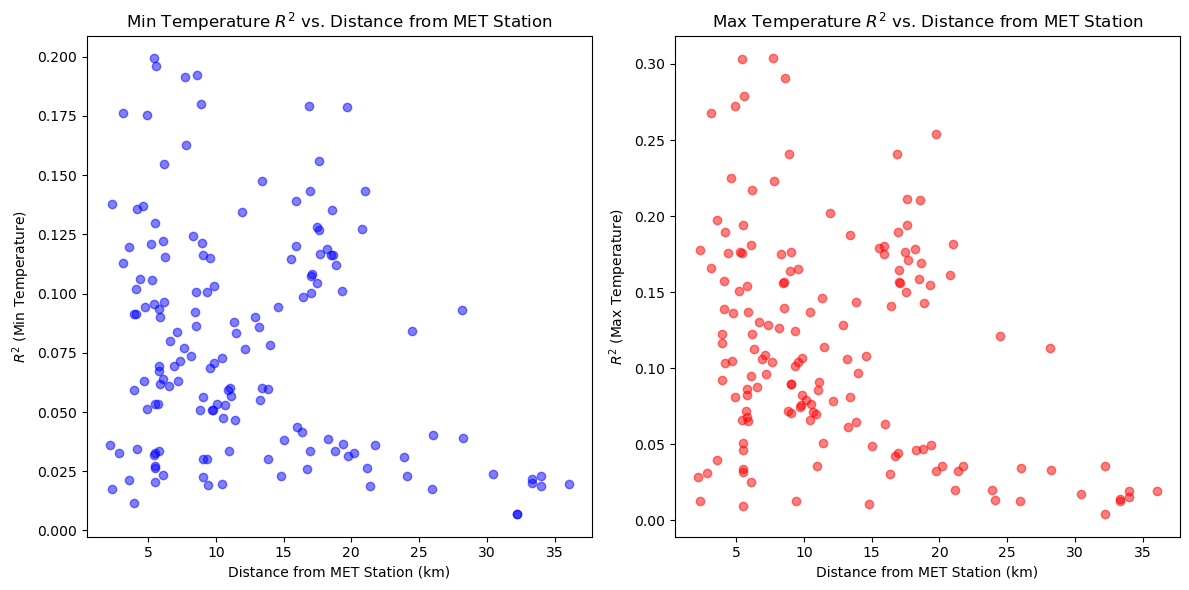

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from geopy.distance import geodesic
from pandas.plotting import register_matplotlib_converters
from tqdm import tqdm
from scipy.stats import spearmanr
import numpy as np

register_matplotlib_converters()

# Load the temperature data
outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')

# Convert 'Date/Time' to datetime format
outdoor_temp_df['Date/Time'] = pd.to_datetime(outdoor_temp_df['Date/Time'])

# Load the MET station data
min_temp_df = pd.read_csv('GMET_data/minimum_temperatures_transformed_sorted.csv')
max_temp_df = pd.read_csv('GMET_data/maximum_temperatures_transformed_sorted.csv')

# Convert the 'DATE' column to datetime
min_temp_df['DATE'] = pd.to_datetime(min_temp_df['DATE'])
max_temp_df['DATE'] = pd.to_datetime(max_temp_df['DATE'])

# Prepare the data for future merging
min_temp_df.set_index('DATE', inplace=True)
max_temp_df.set_index('DATE', inplace=True)

# Rename columns for clarity in merging
min_temp_df.rename(columns={'TEMPERATURE': 'GMET_min'}, inplace=True)
max_temp_df.rename(columns={'TEMPERATURE': 'GMET_max'}, inplace=True)

# Reference point for the MET station
ref_point = (5.6050, -0.1670)

# Filter out rows where Lat or Lon is NaN
filtered_pairs = outdoor_temp_df.dropna(subset=['gps_lat_out', 'gps_long_out'])

# Extract unique latitude-longitude pairs and set them as index
unique_pairs = filtered_pairs[['gps_lat_out', 'gps_long_out']].drop_duplicates()
unique_pairs.set_index(['gps_lat_out', 'gps_long_out'], inplace=True)

# Compute the distance for each unique pair
unique_pairs['distance'] = unique_pairs.index.map(lambda x: geodesic(x, ref_point).km)

# Map these computed distances back to the main dataframe
outdoor_temp_df['distance'] = outdoor_temp_df.set_index(['gps_lat_out', 'gps_long_out']).index.map(unique_pairs['distance'].to_dict())

# Group by sensor and calculate daily max and min temperatures
sensor_daily_max_min = outdoor_temp_df.groupby(['Date/Time', 'sensor_id_outdoor_temp'])['Value'].agg(['max', 'min']).reset_index()

# Merge with MET station data
sensor_daily_max_min['Date'] = sensor_daily_max_min['Date/Time'].dt.date
sensor_daily_max_min.set_index('Date', inplace=True)

# Initialize lists to store R² values and distances
r2_min_values = []
r2_max_values = []
distances = []

# Function to calculate R² for each sensor
def calculate_r2(x, y):
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    if not df.empty:
        X = sm.add_constant(df['x'])
        model = sm.OLS(df['y'], X).fit()
        return model.rsquared
    return None

# Iterate over each sensor
for sensor_id in tqdm(sensor_daily_max_min['sensor_id_outdoor_temp'].unique()):
    sensor_data = sensor_daily_max_min[sensor_daily_max_min['sensor_id_outdoor_temp'] == sensor_id]
    
    # Merge with MET station data
    merged_min_temp = min_temp_df.join(sensor_data[['min']], how='inner')
    merged_max_temp = max_temp_df.join(sensor_data[['max']], how='inner')

    # Calculate R² for minimum temperature
    r2_min = calculate_r2(merged_min_temp['GMET_min'], merged_min_temp['min'])
    
    # Calculate R² for maximum temperature
    r2_max = calculate_r2(merged_max_temp['GMET_max'], merged_max_temp['max'])
    
    if r2_min is not None and r2_max is not None:
        r2_min_values.append(r2_min)
        r2_max_values.append(r2_max)
        # Get distance for the current sensor
        sensor_distance = outdoor_temp_df[outdoor_temp_df['sensor_id_outdoor_temp'] == sensor_id]['distance'].iloc[0]
        distances.append(sensor_distance)

# Function to calculate bootstrap confidence intervals
def bootstrap_ci(data, func, n_bootstrap=1000, ci=95):
    bootstrapped_stats = []
    n = len(data)
    indices = np.arange(n)
    for _ in range(n_bootstrap):
        sample_indices = np.random.choice(indices, size=n, replace=True)
        sample = [data[i] for i in sample_indices]
        stat = func(sample)
        bootstrapped_stats.append(stat)
    lower_bound = np.percentile(bootstrapped_stats, (100 - ci) / 2)
    upper_bound = np.percentile(bootstrapped_stats, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound

# Calculate Spearman correlation for min and max temperatures
spearman_corr_min, spearman_p_min = spearmanr(distances, r2_min_values)
spearman_corr_max, spearman_p_max = spearmanr(distances, r2_max_values)

# Calculate bootstrap confidence intervals for Spearman correlations
spearman_ci_min = bootstrap_ci(list(zip(distances, r2_min_values)), lambda s: spearmanr(*zip(*s))[0])
spearman_ci_max = bootstrap_ci(list(zip(distances, r2_max_values)), lambda s: spearmanr(*zip(*s))[0])

print(f"Spearman correlation between distance and R² (Min Temperature): {spearman_corr_min:.2f} (95% CI: {spearman_ci_min[0]:.2f}, {spearman_ci_min[1]:.2f}), p-value: {spearman_p_min:.4f}")
print(f"Spearman correlation between distance and R² (Max Temperature): {spearman_corr_max:.2f} (95% CI: {spearman_ci_max[0]:.2f}, {spearman_ci_max[1]:.2f}), p-value: {spearman_p_max:.4f}")

# Plot the relationship between R² and distance for min and max temperatures
plt.figure(figsize=(12, 6))

# Min temperature R² vs. Distance
plt.subplot(1, 2, 1)
plt.scatter(distances, r2_min_values, c='blue', alpha=0.5)
plt.xlabel('Distance from MET Station (km)')
plt.ylabel('$R^2$ (Min Temperature)')
plt.title('Min Temperature $R^2$ vs. Distance from MET Station')

# Max temperature R² vs. Distance
plt.subplot(1, 2, 2)
plt.scatter(distances, r2_max_values, c='red', alpha=0.5)
plt.xlabel('Distance from MET Station (km)')
plt.ylabel('$R^2$ (Max Temperature)')
plt.title('Max Temperature $R^2$ vs. Distance from MET Station')

plt.tight_layout()
plt.savefig('R2_vs_Distance.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_32668/2827585191.py:11: DtypeWarning: Columns (7,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')
  9%|███████████████                                                                                                                                                      | 14/154 [00:00<00:01, 136.47it/s]

Sensor ID: '0A27' - Number of overlapping days (Min Temp): 302, (Max Temp): 302
Sensor ID: '0A27'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 40
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '42E6' - Number of overlapping days (Min Temp): 239, (Max Temp): 239
Sensor ID: '42E6'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 135
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '52A5' - Number of overlapping days (Min Temp): 302, (Max Temp): 302
Sensor ID: '52A5'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 115
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '74FB' - Number of overlapping days (Min Temp): 302, (Max Temp): 302
Sensor ID: '74FB'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 20
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '834D' - Number of overlapping days (Min Temp): 302, (Max Temp): 302
Sensor ID: '834D'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 107
Hot Min Nights (GMET): 0, Hot Min Nights (Sen

 36%|████████████████████████████████████████████████████████████                                                                                                         | 56/154 [00:00<00:00, 133.58it/s]

Sensor ID: '722B' - Number of overlapping days (Min Temp): 289, (Max Temp): 289
Sensor ID: '722B'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 123
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '8467' - Number of overlapping days (Min Temp): 289, (Max Temp): 289
Sensor ID: '8467'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 180
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: 'F137' - Number of overlapping days (Min Temp): 289, (Max Temp): 289
Sensor ID: 'F137'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 123
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '1372' - Number of overlapping days (Min Temp): 288, (Max Temp): 288
Sensor ID: '1372'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 173
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '5814' - Number of overlapping days (Min Temp): 255, (Max Temp): 255
Sensor ID: '5814'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 166
Hot Min Nights (GMET): 0, Hot Min Nights (S

 56%|████████████████████████████████████████████████████████████████████████████████████████████▏                                                                        | 86/154 [00:00<00:00, 138.47it/s]

...

Sensor ID: '7F2E' - Number of overlapping days (Min Temp): 149, (Max Temp): 149
Sensor ID: '7F2E'
Hot Max Days (GMET): 1, Hot Max Days (Sensor): 68
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: 'A393' - Number of overlapping days (Min Temp): 244, (Max Temp): 244
Sensor ID: 'A393'
Hot Max Days (GMET): 1, Hot Max Days (Sensor): 55
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '107E' - Number of overlapping days (Min Temp): 250, (Max Temp): 250
Sensor ID: '107E'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 68
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '5A60' - Number of overlapping days (Min Temp): 253, (Max Temp): 253
Sensor ID: '5A60'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 197
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '5E26' - Number of overlapping days (Min Temp): 95, (Max Temp): 95
Sensor ID: '5E26'
Hot Max Days (GMET): 0, Hot Max Days (Sensor): 1
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor):

 95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍        | 146/154 [00:01<00:00, 140.96it/s]

Sensor ID: '7438' - Number of overlapping days (Min Temp): 240, (Max Temp): 240
Sensor ID: '7438'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 151
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '7836' - Number of overlapping days (Min Temp): 240, (Max Temp): 240
Sensor ID: '7836'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 175
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '9795' - Number of overlapping days (Min Temp): 240, (Max Temp): 240
Sensor ID: '9795'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 140
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: 'EE10' - Number of overlapping days (Min Temp): 240, (Max Temp): 240
Sensor ID: 'EE10'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 177
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: 'F11A' - Number of overlapping days (Min Temp): 240, (Max Temp): 240
Sensor ID: 'F11A'
Hot Max Days (GMET): 2, Hot Max Days (Sensor): 165
Hot Min Nights (GMET): 0, Hot Min Nights (S

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 154/154 [00:01<00:00, 138.88it/s]


Sensor ID: '049B' - Number of overlapping days (Min Temp): 43, (Max Temp): 43
Sensor ID: '049B'
Hot Max Days (GMET): 0, Hot Max Days (Sensor): 16
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: 'EF31' - Number of overlapping days (Min Temp): 31, (Max Temp): 31
Sensor ID: 'EF31'
Hot Max Days (GMET): 0, Hot Max Days (Sensor): 14
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '0BC7' - Number of overlapping days (Min Temp): 21, (Max Temp): 21
Sensor ID: '0BC7'
Hot Max Days (GMET): 0, Hot Max Days (Sensor): 7
Hot Min Nights (GMET): 0, Hot Min Nights (Sensor): 0
Sensor ID: '8704' - Number of overlapping days (Min Temp): 0, (Max Temp): 0
Sensor ID: '1446' - Number of overlapping days (Min Temp): 0, (Max Temp): 0


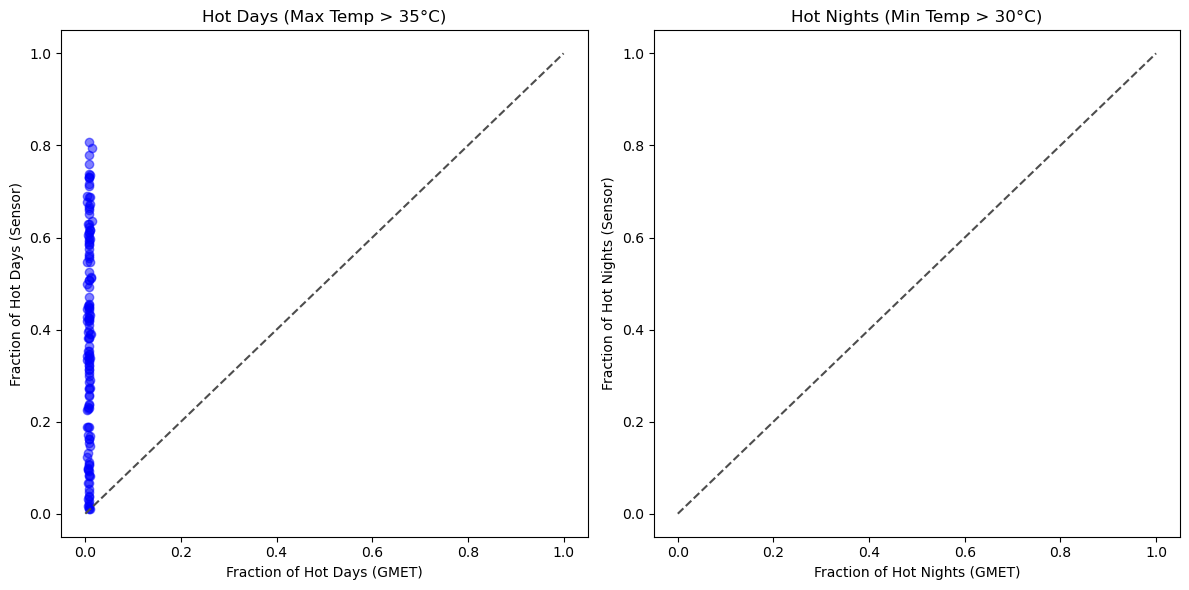

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from geopy.distance import geodesic
from pandas.plotting import register_matplotlib_converters
from tqdm import tqdm

register_matplotlib_converters()

# Load the temperature data
outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')

# Convert 'Date/Time' to datetime format and extract the date
outdoor_temp_df['Date/Time'] = pd.to_datetime(outdoor_temp_df['Date/Time'])
outdoor_temp_df['Date'] = outdoor_temp_df['Date/Time'].dt.date

# Group the data by date and 'sensor_id_outdoor_temp' to find the daily max and min temperatures for each sensor
daily_max_min_per_sensor = outdoor_temp_df.groupby(['Date', 'sensor_id_outdoor_temp'])['Value'].agg(['max', 'min']).reset_index()

# Load the MET station data
min_temp_df = pd.read_csv('GMET_data/minimum_temperatures_transformed_sorted.csv')
max_temp_df = pd.read_csv('GMET_data/maximum_temperatures_transformed_sorted.csv')

# Convert the 'DATE' column to datetime
min_temp_df['DATE'] = pd.to_datetime(min_temp_df['DATE'])
max_temp_df['DATE'] = pd.to_datetime(max_temp_df['DATE'])

# Prepare the data for future merging
min_temp_df.set_index('DATE', inplace=True)
max_temp_df.set_index('DATE', inplace=True)

# Rename columns for clarity in merging
min_temp_df.rename(columns={'TEMPERATURE': 'GMET_min'}, inplace=True)
max_temp_df.rename(columns={'TEMPERATURE': 'GMET_max'}, inplace=True)

# Reference point for the MET station
ref_point = (5.6050, -0.1670)

# Filter out rows where Lat or Lon is NaN
filtered_pairs = outdoor_temp_df.dropna(subset=['gps_lat_out', 'gps_long_out'])

# Extract unique latitude-longitude pairs and set them as index
unique_pairs = filtered_pairs[['gps_lat_out', 'gps_long_out']].drop_duplicates()
unique_pairs.set_index(['gps_lat_out', 'gps_long_out'], inplace=True)

# Compute the distance for each unique pair
unique_pairs['distance'] = unique_pairs.index.map(lambda x: geodesic(x, ref_point).km)

# Map these computed distances back to the main dataframe
outdoor_temp_df['distance'] = outdoor_temp_df.set_index(['gps_lat_out', 'gps_long_out']).index.map(unique_pairs['distance'].to_dict())

# Initialize lists to store hot day and night fractions
hot_day_fractions_met = []
hot_day_fractions_sensor = []
hot_night_fractions_met = []
hot_night_fractions_sensor = []

# Function to calculate the number and fraction of hot days
def calculate_hot_days(df, column, threshold):
    hot_days = df[df[column] > threshold]
    total_days = len(df)
    hot_days_count = len(hot_days)
    hot_days_fraction = hot_days_count / total_days if total_days > 0 else 0
    return hot_days_count, hot_days_fraction

# Iterate over each sensor
for sensor_id in tqdm(daily_max_min_per_sensor['sensor_id_outdoor_temp'].unique()):
    sensor_data = daily_max_min_per_sensor[daily_max_min_per_sensor['sensor_id_outdoor_temp'] == sensor_id]
    sensor_data.set_index('Date', inplace=True)
    
    # Merge with MET station data
    merged_min_temp = min_temp_df.join(sensor_data[['min']], how='inner')
    merged_max_temp = max_temp_df.join(sensor_data[['max']], how='inner')

    # Debugging: Check the number of days in merged data
    num_days_min = len(merged_min_temp)
    num_days_max = len(merged_max_temp)
    print(f"Sensor ID: {sensor_id} - Number of overlapping days (Min Temp): {num_days_min}, (Max Temp): {num_days_max}")
    
    # Ensure there is overlapping data
    if num_days_min > 0 and num_days_max > 0:
        # Calculate the number and fraction of hot days (max temp > 35°C)
        hot_max_met_count, hot_max_met_fraction = calculate_hot_days(merged_max_temp, 'GMET_max', 35)
        hot_max_sensor_count, hot_max_sensor_fraction = calculate_hot_days(merged_max_temp, 'max', 35)

        # Calculate the number and fraction of hot nights (min temp > 30°C)
        hot_min_met_count, hot_min_met_fraction = calculate_hot_days(merged_min_temp, 'GMET_min', 30)
        hot_min_sensor_count, hot_min_sensor_fraction = calculate_hot_days(merged_min_temp, 'min', 30)

        # Append to the lists only if there is valid data
        if hot_max_met_count > 0 and hot_max_sensor_count > 0:
            hot_day_fractions_met.append(hot_max_met_fraction)
            hot_day_fractions_sensor.append(hot_max_sensor_fraction)
        
        if hot_min_met_count > 0 and hot_min_sensor_count > 0:
            hot_night_fractions_met.append(hot_min_met_fraction)
            hot_night_fractions_sensor.append(hot_min_sensor_fraction)

        print(f"Sensor ID: {sensor_id}")
        print(f"Hot Max Days (GMET): {hot_max_met_count}, Hot Max Days (Sensor): {hot_max_sensor_count}")
        print(f"Hot Min Nights (GMET): {hot_min_met_count}, Hot Min Nights (Sensor): {hot_min_sensor_count}")

# Plot the relationship between fraction of hot days/nights for GMET vs sensor data
plt.figure(figsize=(12, 6))

# Hot days (max temp > 35°C)
plt.subplot(1, 2, 1)
plt.scatter(hot_day_fractions_met, hot_day_fractions_sensor, c='blue', alpha=0.5)
plt.xlabel('Fraction of Hot Days (GMET)')
plt.ylabel('Fraction of Hot Days (Sensor)')
plt.title('Hot Days (Max Temp > 35°C)')
plt.plot([0, 1], [0, 1], ls="--", c=".3")

# Hot nights (min temp > 30°C)
plt.subplot(1, 2, 2)
plt.scatter(hot_night_fractions_met, hot_night_fractions_sensor, c='red', alpha=0.5)
plt.xlabel('Fraction of Hot Nights (GMET)')
plt.ylabel('Fraction of Hot Nights (Sensor)')
plt.title('Hot Nights (Min Temp > 30°C)')
plt.plot([0, 1], [0, 1], ls="--", c=".3")

plt.tight_layout()
plt.savefig('Hot_Days_Nights_Sensor_vs_GMET.png', bbox_inches='tight')
plt.show()


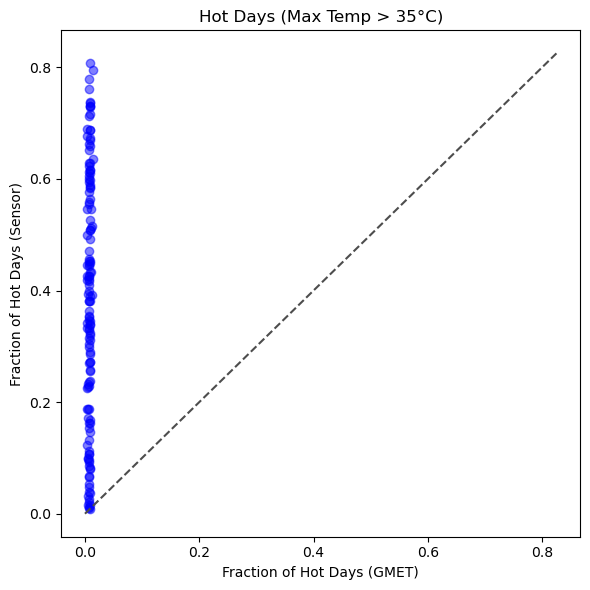

In [24]:
# Plot the relationship between fraction of hot days/nights for GMET vs sensor data
plt.figure(figsize=(6, 6))

# Hot days (max temp > 35°C)
plt.scatter(hot_day_fractions_met, hot_day_fractions_sensor, c='blue', alpha=0.5)
plt.xlabel('Fraction of Hot Days (GMET)')
plt.ylabel('Fraction of Hot Days (Sensor)')
plt.title('Hot Days (Max Temp > 35°C)')
plt.plot([0, 0.825], [0, 0.825], ls="--", c=".3")

plt.tight_layout()
plt.savefig('Hot_Days_Nights_Sensor_vs_GMET.png', bbox_inches='tight')
plt.show()